# General Architecture
---

![Seq2seq](https://docs.chainer.org/en/stable/_images/seq2seq.png)

([Source](https://docs.chainer.org/en/stable/examples/seq2seq.html))

Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
%%capture
!pip install watermark
!pip install torchinfo datasets

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.9.0+cu126



-----

# Encoder-Decoder (Seq2Seq) Architecture for Statistical Machine Translation

The network in this notebook is a foundational implementation of the **Sequence-to-Sequence (Seq2Seq)** architecture **[1, 2]** on the **Multi30k** (a standard English-to-German translation dataset) dataset. This marks the transition from classification (mapping text to a label) to **transduction** (mapping one sequence to another). This architecture is the ancestor of modern translation systems and conversational AI.

![](https://d2l.ai/_images/seq2seq.svg)

(Source, **[4]**)

<br><br>

## **Network Architecture:**

The Basic Seq2Seq model operates on a "Message Passing" principle using two distinct modules:

1.  **The Encoder:** It processes the entire input sequence and "summarizes" it into a single fixed-size vector, known as the **Context Vector** (the final hidden state).
2.  **The Decoder:** It takes that single Context Vector as its initial hidden state and its "starting point" to begin generating the output sequence, one token at a time, until it produces an `<EOS>` (End of Sentence) token.



<br><br>


#### **Encoder**

![](https://raw.githubusercontent.com/bentrevett/pytorch-seq2seq/refs/heads/main/assets/seq2seq2.png)

([Source](https://github.com/bentrevett/pytorch-seq2seq/blob/main/assets/seq2seq2.png))<br><br>

#### **Decoder**

![](https://raw.githubusercontent.com/bentrevett/pytorch-seq2seq/refs/heads/main/assets/seq2seq3.png)

([Source](https://github.com/bentrevett/pytorch-seq2seq/blob/main/assets/seq2seq3.png))<br><br>

#### **Seq2Seq**

![](https://raw.githubusercontent.com/bentrevett/pytorch-seq2seq/refs/heads/main/assets/seq2seq4.png)

([Source](https://github.com/bentrevett/pytorch-seq2seq/blob/main/assets/seq2seq4.png))<br><br>

-----

## **Key Concepts of the `Basic Seq2Seq` Architecture:**

1.  **The Fixed-Length Bottleneck:** The core challenge of this model is that the *entire* meaning of the source sentence—no matter how long—must be packed into a single hidden state vector.
2.  **Hidden State Transfer:** The final hidden state of the Encoder ($h_N$) acts as the "bridge." It is the only piece of information the Decoder receives about the input.
3.  **Autoregressive Generation:** The Decoder is "autoregressive," meaning its own prediction at time step $t$ becomes its input for time step $t+1$.
4.  **Symmetry of RNNs:** While the Encoder and Decoder are separate modules with their own weights, they are typically built using the same type of cell (e.g., GRU or LSTM) to ensure the hidden state dimensions match.
5.  **Teacher Forcing:** During training, we occasionally "force" the correct ground-truth word into the Decoder instead of its own prediction to keep the training stable.

<br><br>

-----

## **Quick Comparison: Many-to-One (Classify) vs. Many-to-Many (Seq2Seq)**

| Feature | Classification (AG News) | Seq2Seq (Translation) |
| :--- | :--- | :--- |
| **Output Type** | Single Category / Label | **Entire New Sequence** |
| **Length Constraint** | N/A (Fixed 1 output) | **Dynamic (Output length $\neq$ Input length)** |
| **Decoder Module** | Simple Linear Layer | **Recurrent GRU/LSTM Layer** |
| **Loss Function** | CrossEntropy (Single) | **CrossEntropy (Per Time-Step)** |
| **Training Trick** | Standard Backprop | **Teacher Forcing** |
| **Primary Goal** | Discrimination / Understanding | **Transformation / Generation** |
| **Primary Metric** | Accuracy / F1 Score | **Perplexity (PPL)** |

<br><br>

-----

**REFERENCES:**

1.  Sutskever, Ilya, Oriol Vinyals, and Quoc V. Le. ["Sequence to sequence learning with neural networks."](https://arxiv.org/abs/1409.3215) *NeurIPS*, 2014. **(The "Seq2Seq" Origin)**
2.  Cho, Kyunghyun, et al. ["Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation."](https://arxiv.org/abs/1406.1078) *arXiv preprint arXiv:1406.1078*, 2014. **(Original GRU + Seq2Seq)**
3.  Bahdanau, Dzmitry, et al. ["Neural machine translation by jointly learning to align and translate."](https://arxiv.org/abs/1409.0473) *arXiv*, 2014.
4.  Zhang, Aston, et al. ["Sequence to Sequence Learning."](https://d2l.ai/chapter_recurrent-modern/seq2seq.html) *Dive into Deep Learning*, Ch. 10.7. **(Excellent Textbook Breakdown)**
5.  Elliott, Desmond, et al. ["Multi30k: Multilingual Extended Descriptional Images."](https://aclanthology.org/W16-3210) *Proc. 5th Workshop on Vision and Language*, 2016. **(Core Dataset Source)**
6.  Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI

-----

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Sampler, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS (Seq2Seq)
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 50 #15        

# Vocabulary & Architecture
VOCABULARY_SIZE = 10000 
ENC_EMBED_DIM = 256
DEC_EMBED_DIM = 256
HIDDEN_DIM = 512       # Needs high capacity for the Context Vector bottleneck
DROPOUT_P = 0.5 
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

# Seq2Seq Specifics
TEACHER_FORCING_RATIO = 0.5 

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load Dataset (Translation: English to German)
DATASET_CONFIG = "bentrevett/multi30k" 
raw_datasets = load_dataset(DATASET_CONFIG)

ds_splits = DatasetDict({
    'train': raw_datasets['train'],
    'validation': raw_datasets['validation'], 
    'test': raw_datasets['test']
})

print(f"\n[ROBUST CONFIG COMPLETE]")
print(f"Dataset: {DATASET_CONFIG} | Task: EN to DE Translation")

# 2. Build Dual Vocabularies (Source and Target)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
en_counts, de_counts = Counter(), Counter()

for item in ds_splits['train']:
    en_counts.update(tokenizer(item['en']))
    de_counts.update(tokenizer(item['de']))

# Special Tokens are critical for Seq2Seq
SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']

def build_vocab(counts, max_size):
    vocab = {word: i for i, word in enumerate(SPECIAL_TOKENS)}
    for word, _ in counts.most_common(max_size - len(SPECIAL_TOKENS)):
        vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab(en_counts, VOCABULARY_SIZE)
trg_vocab = build_vocab(de_counts, VOCABULARY_SIZE)

SRC_PAD_IDX = src_vocab['<PAD>']
TRG_PAD_IDX = trg_vocab['<PAD>']

print(f"Source (EN) Vocab size: {len(src_vocab)}")
print(f"Target (DE) Vocab size: {len(trg_vocab)}")


# 3. Robust Collate Batch for Seq2Seq
def collate_batch(batch):
    src_list, trg_list = [], []
    
    for item in batch:
        # Source pipeline: <SOS> + tokens + <EOS>; reversing the source sentence (The Sutskever Trick)
        src_toks = [src_vocab['<SOS>']] + [src_vocab.get(t, src_vocab['<UNK>']) for t in tokenizer(item['en'])][::-1] + [src_vocab['<EOS>']]
        # Target pipeline: <SOS> + tokens + <EOS>
        trg_toks = [trg_vocab['<SOS>']] + [trg_vocab.get(t, trg_vocab['<UNK>']) for t in tokenizer(item['de'])] + [trg_vocab['<EOS>']]
        
        src_list.append(torch.tensor(src_toks, dtype=torch.int64))
        trg_list.append(torch.tensor(trg_toks, dtype=torch.int64))

    # Pad on CPU, Batch First
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=SRC_PAD_IDX)
    trg_padded = pad_sequence(trg_list, batch_first=True, padding_value=TRG_PAD_IDX)

    return src_padded, trg_padded

# 4. Initialize DataLoaders
loader_kwargs = {
    'batch_size': BATCH_SIZE,
    'collate_fn': collate_batch,
    'pin_memory': True, 
    'num_workers': 2
}

train_loader = DataLoader(ds_splits['train'], shuffle=True, **loader_kwargs)
val_loader   = DataLoader(ds_splits['validation'], shuffle=False, **loader_kwargs)
test_loader  = DataLoader(ds_splits['test'], shuffle=False, **loader_kwargs)

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]


[ROBUST CONFIG COMPLETE]
Dataset: bentrevett/multi30k | Task: EN to DE Translation
Source (EN) Vocab size: 9766
Target (DE) Vocab size: 10000


---
# 2. Model Creation

---


In [7]:
# --- JIT FUSED LSTM CELL (From Scratch) ---
@torch.jit.script
def fused_lstm_logic(gate_x, gate_h, c_prev):
    # LSTM gate calculation: Input, Forget, Cell, Output
    gates = gate_x + gate_h
    i, f, g, o = gates.chunk(4, 1)

    i = torch.sigmoid(i)
    f = torch.sigmoid(f)
    g = torch.tanh(g)
    o = torch.sigmoid(o)

    # Cell state update
    c_curr = (f * c_prev) + (i * g)
    # Hidden state update
    h_curr = o * torch.tanh(c_curr)

    return h_curr, c_curr

class LSTMCellFromScratch(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.x2h = nn.Linear(input_size, 4 * hidden_size)
        self.h2h = nn.Linear(hidden_size, 4 * hidden_size)

    def forward(self, x: torch.Tensor, states: tuple[torch.Tensor, torch.Tensor]):
        h_prev, c_prev = states
        gate_x = self.x2h(x)
        gate_h = self.h2h(h_prev)
        return fused_lstm_logic(gate_x, gate_h, c_prev)

# --- JIT FUSED GRU CELL (From Scratch) ---
@torch.jit.script
def fused_gru_logic(i_r, i_z, i_n, h_r, h_z, h_n, h):
    reset_gate = torch.sigmoid(i_r + h_r)
    update_gate = torch.sigmoid(i_z + h_z)
    new_gate = torch.tanh(i_n + (reset_gate * h_n))
    return (1.0 - update_gate) * h + update_gate * new_gate

class GRUCellFromScratch(nn.Module):
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        self.x2h = nn.Linear(input_size, 3 * hidden_size)
        self.h2h = nn.Linear(hidden_size, 3 * hidden_size)

    def forward(self, x: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
        gate_x = self.x2h(x)
        gate_h = self.h2h(h)
        i_r, i_z, i_n = gate_x.chunk(3, 1)
        h_r, h_z, h_n = gate_h.chunk(3, 1)
        return fused_gru_logic(i_r, i_z, i_n, h_r, h_z, h_n, h)

In [8]:
# --- ROBUST ENCODER ---
class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, dropout_p, cell_type='GRU'):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell_type = cell_type # 'GRU' or 'LSTM'
        self.embedding = nn.Embedding(input_dim, embed_dim)
        self.dropout = nn.Dropout(dropout_p)
        
        if cell_type == 'LSTM':
            self.rnn_cell = LSTMCellFromScratch(embed_dim, hidden_dim)
        else:
            self.rnn_cell = GRUCellFromScratch(embed_dim, hidden_dim)

    def forward(self, src):
        batch_size, seq_len = src.shape
        embedded = self.dropout(self.embedding(src))
        
        # Initialize hidden state
        h = torch.zeros(batch_size, self.hidden_dim, device=src.device)
        
        if self.cell_type == 'LSTM':
            # LSTM needs an additional Cell State (c)
            c = torch.zeros(batch_size, self.hidden_dim, device=src.device)
            for t in range(seq_len):
                h, c = self.rnn_cell(embedded[:, t, :], (h, c))
            return (h, c) # Return tuple for LSTM
        else:
            # GRU only uses h
            for t in range(seq_len):
                h = self.rnn_cell(embedded[:, t, :], h)
            return h

# --- ROBUST DECODER ---
class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, dropout_p, cell_type='GRU'):
        super().__init__()
        self.cell_type = cell_type
        self.output_dim = output_dim
        self.embedding = nn.Embedding(output_dim, embed_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        
        if cell_type == 'LSTM':
            self.rnn_cell = LSTMCellFromScratch(embed_dim, hidden_dim)
        else:
            self.rnn_cell = GRUCellFromScratch(embed_dim, hidden_dim)

    def forward(self, input_token, state):
        embedded = self.dropout(self.embedding(input_token)) 
        
        if self.cell_type == 'LSTM':
            # state is (h, c)
            h, c = self.rnn_cell(embedded, state)
            prediction = self.fc_out(h)
            return prediction, (h, c)
        else:
            # state is just h
            h = self.rnn_cell(embedded, state)
            prediction = self.fc_out(h)
            return prediction, h

# --- ROBUST MASTER SEQ2SEQ ---
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        trg_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        
        # 1. Get initial state from Encoder (could be h or (h, c))
        state = self.encoder(src)
        
        # 2. First input to decoder
        input_token = trg[:, 0]
        
        for t in range(1, trg_len):
            output, state = self.decoder(input_token, state)
            outputs[:, t, :] = output
            
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if teacher_force else output.argmax(1)
            
        return outputs

def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)

In [9]:
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512, text_key='en'):
    # 1. Get the statistical length using the dictionary key
    # ex is a dict like {'en': '...', 'de': '...'}
    lengths = [len(tokenizer(ex[text_key])) for ex in dataset]
    
    p_length = np.percentile(lengths, p)

    # 2. Find the next power of 2
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))

    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)

    print(f"Source Key: {text_key}")
    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")

    return final_len

# Usage - Ensure 'en' matches your dataset column name
MAX_LEN_SRC = get_robust_maxlen(ds_splits['train'], tokenizer, p=95, text_key='en')
print('\n')
MAX_LEN_TRG = get_robust_maxlen(ds_splits['train'], tokenizer, p=95, text_key='de')

# Final Robust Cap for Tensors
MAX_LEN = max(MAX_LEN_SRC, MAX_LEN_TRG)
print(f"\nGlobal MAX_LEN set to: {MAX_LEN}")

Source Key: en
95th Percentile: 19.00
Nearest Power of 2: 32
Final Robust MAX_LEN: 32


Source Key: de
95th Percentile: 18.00
Nearest Power of 2: 32
Final Robust MAX_LEN: 32

Global MAX_LEN set to: 32


In [10]:
DATASET_CONFIG, MAX_LEN_SRC, MAX_LEN_TRG, MAX_LEN

('bentrevett/multi30k', 32, 32, 32)

In [11]:
def count_parameters_seq2seq(model):
    def count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

    # Breakdown by Sub-Module
    enc_params = count(model.encoder)
    dec_params = count(model.decoder)
    total_params = enc_params + dec_params

    # Further breakdown (optional but professional)
    enc_emb = count(model.encoder.embedding)
    dec_emb = count(model.decoder.embedding)
    
    # The 'brain' is the RNN/LSTM/GRU layers
    # We subtract embeddings and the output layer (fc_out) from the decoder
    dec_rnn = dec_params - dec_emb - count(model.decoder.fc_out)
    enc_rnn = enc_params - enc_emb

    print(f"{'Component':<20} | {'Parameters':<12}")
    print("-" * 35)
    print(f"{'Encoder Embedding':<20} | {enc_emb:,}")
    print(f"{'Encoder RNN':<20} | {enc_rnn:,}")
    print(f"{'Decoder Embedding':<20} | {dec_emb:,}")
    print(f"{'Decoder RNN':<20} | {dec_rnn:,}")
    print(f"{'Output Projection':<20} | {count(model.decoder.fc_out):,}")
    print("-" * 35)
    print(f"{'TOTAL TRAINABLE':<20} | {total_params:,}")

---
# 3. Model Training, Testing & Evaluation

---

In [12]:
def evaluate_seq2seq(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    with torch.no_grad():
        for src, trg in data_loader:
            src, trg = src.to(device), trg.to(device)
            
            # 1. Forward pass (No Teacher Forcing)
            output = model(src, trg, teacher_forcing_ratio=0)
            
            # output shape: [batch_size, trg_len, trg_vocab_size]
            # trg shape:    [batch_size, trg_len]
            output_dim = output.shape[-1]
            
            # 1. Slice off <SOS> token (index 0) from the sequence length dimension
            # 2. Reshape to flatten Batch and Sequence dimensions into one [N] dimension
            # Resulting output: [(trg_len - 1) * batch_size, trg_vocab_size]
            # Resulting trg:    [(trg_len - 1) * batch_size]
            
            output = output[:, 1:, :].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)
            
            # Now the dimensions match what nn.CrossEntropyLoss expects
            loss = criterion(output, trg)
            
            # 4. Global Accumulation
            # Count only non-padding tokens for weighted average
            n_tokens = (trg != TRG_PAD_IDX).sum().item()
            
            # Recover total loss for this batch and add to global sum
            total_loss += loss.item() * n_tokens
            total_tokens += n_tokens
            
    # Final Academic Metrics
    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)
    bpc = avg_loss / math.log(2)
    
    return avg_loss, ppl, bpc

In [13]:
def train_seq2seq(model, train_loader, val_loader, optimizer, criterion, scheduler, num_epochs, device, patience=5):
    scaler = torch.amp.GradScaler('cuda')
    start_time = time.time()
    best_val_loss = float('inf')
    epochs_no_improve = 0 
    
    history = {'train_loss': [], 'val_loss': [], 'val_ppl': [], 'val_bpc': [], 'lrs': []}

    print(f"Starting Seq2Seq training on {device}...")

    for epoch in range(num_epochs):
        model.train()
        train_running_loss = 0.0

        for src, trg in train_loader:
            src, trg = src.to(device, non_blocking=True), trg.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                output = model(src, trg, TEACHER_FORCING_RATIO)
                output_dim = output.shape[-1]
                
                # Flatten and ignore <SOS>
                output = output[:, 1:, :].reshape(-1, output_dim)
                trg = trg[:, 1:].reshape(-1)
                
                loss = criterion(output, trg)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_running_loss += loss.item()

        # Epoch Metrics
        epoch_train_loss = train_running_loss / len(train_loader)
        epoch_val_loss, epoch_val_ppl, epoch_val_bpc = evaluate_seq2seq(model, val_loader, criterion, device)

        # Early Stopping & Checkpoint
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'best_seq2seq.pth')
            epochs_no_improve = 0
            status_msg = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status_msg = f" (No improve: {epochs_no_improve}/{patience})"

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Update History
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_ppl'].append(epoch_val_ppl)
        history['val_bpc'].append(epoch_val_bpc) # Add BPC to history
        history['lrs'].append(current_lr)

        print(f'Epoch {epoch + 1:03d}/{num_epochs:03d} | '
              f'Loss (T/V): {epoch_train_loss:.4f} / {epoch_val_loss:.4f} | '
              f'PPL (V): {epoch_val_ppl:.2f} | '
              f'BPC (V): {epoch_val_bpc:.4f} | '
              f'LR: {current_lr:.6f}{status_msg}')

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f'\nDone! Total Time: {(time.time() - start_time) / 60:.2f} min')
    model.load_state_dict(torch.load('best_seq2seq.pth'))
    return history

In [14]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Identify which metrics were tracked
    has_acc = 'val_acc' in history
    has_f1  = 'val_f1' in history
    has_gen = 'val_ppl' in history
    
    # Dynamic grid layout
    num_plots = 2 + int(has_acc) + int(has_f1) + int(has_gen)
    plt.figure(figsize=(num_plots * 5, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, num_plots, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train ', color='#1f77b4')
    plt.plot(epochs, history['val_loss'], 's--', label='Val', color='#ff7f0e')
    plt.title('Cross Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_idx = 2

    # --- Plot 2: Accuracy ---
    if has_acc:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train', color='#1f77b4')
        plt.plot(epochs, np.array(history['val_acc']) * 100, 's--', label='Val', color='#ff7f0e')
        plt.title('Accuracy (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 3: F1 Score ---
    if has_f1:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['val_f1']) * 100, 'd-', label='Val F1', color='#2ca02c')
        plt.title('F1 Score (%)')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 4: Generative Metrics (PPL & BPC) ---
    if has_gen:
        plt.subplot(1, num_plots, plot_idx)
        ax1 = plt.gca()
        
        # PPL on Primary Y-Axis
        ax1.plot(epochs, history['val_ppl'], 'o-', label='PPL', color='purple')
        ax1.set_ylabel('Perplexity', color='purple', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='purple')
        
        if 'val_bpc' in history:
            # BPC on Secondary Y-Axis
            ax2 = ax1.twinx()
            ax2.plot(epochs, history['val_bpc'], 'x--', label='BPC', color='red')
            ax2.set_ylabel('Bits Per Character (BPC)', color='red', fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='red')
            ax2.grid(False) 
            
        plt.title('Generative Metrics')
        ax1.set_xlabel('Epochs')
        ax1.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 5: Learning Rate ---
    plt.subplot(1, num_plots, num_plots)
    plt.plot(epochs, history['lrs'], label='LR', color='black', linewidth=2)
    plt.title('LR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Rate')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
# 4. Model Inference

---

In [15]:
def translate_robust(model, sentence, src_vocab, trg_vocab, tokenizer, device, max_len=50):
    model.eval()

    # Step A: Tokenize & Numericalize Source
    tokens = tokenizer(sentence)
    # The Sutskever Trick: Reverse source if you implemented it in collate_batch
    tokens = tokens[::-1] 
    
    indexed = [src_vocab['<SOS>']] + [src_vocab.get(t, src_vocab['<UNK>']) for t in tokens] + [src_vocab['<EOS>']]
    src_tensor = torch.LongTensor(indexed).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Step B: Get Context Vector from Encoder
        # This handles the (h, c) tuple automatically if using our robust LSTM/GRU Encoder
        state = model.encoder(src_tensor)
        
    # Step C: Recursive Decoding
    trg_indexes = [trg_vocab['<SOS>']]
    
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        
        with torch.no_grad():
            output, state = model.decoder(trg_tensor, state)
            
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        
        # Stop if model predicts End of Sentence
        if pred_token == trg_vocab['<EOS>']:
            break
            
    # Step D: Map back to human-readable strings
    reverse_trg_vocab = {v: k for k, v in trg_vocab.items()}
    translated_words = [reverse_trg_vocab[i] for i in trg_indexes]
    
    # Remove <SOS> and <EOS> for the final output
    return " ".join(translated_words[1:-1])

In [16]:
def run_translation_suite(model, test_sentences, src_vocab, trg_vocab, tokenizer, device):
    """
    Runs a batch of translation tests and prints a professional, formatted report.
    """
    print(f"{'Source Sentence (English)':<55} | {'Model Translation (German)'}")
    print("-" * 110)
    
    for text in test_sentences:
        # Use our generative inference function
        translation = translate_robust(
            model, text, src_vocab, trg_vocab, tokenizer, device
        )
        
        # Truncate source for clean table view, but show full translation
        source_display = text[:52] + "..." if len(text) > 52 else text
        print(f"{source_display:<55} | {translation}")

---
# 5. Final Evaluation/Audit (Statistical & Qualitative)

---

In [17]:
def calculate_bleu(data, model, src_vocab, trg_vocab, tokenizer, device):
    """
    Calculates the average BLEU-4 score across the dataset using NLTK.
    """
    bleu_scores = []
    # Smoothing function handles cases where there are no 4-gram overlaps 
    # (very common in early training) so the score doesn't just drop to 0.
    smoothie = SmoothingFunction().method1
    
    # We use a subset for a quick audit (e.g., 500 samples) to save time
    audit_subset = data if len(data) < 500 else data.select(range(500))
    
    for datum in audit_subset:
        src = datum['en']
        trg = datum['de']
        
        # 1. Get model prediction (string)
        prediction = translate_robust(model, src, src_vocab, trg_vocab, tokenizer, device)
        
        # 2. Tokenize for NLTK
        # Reference must be a list of lists: [[ref1_tok1, ref1_tok2]]
        # Candidate must be a list: [cand_tok1, cand_tok2]
        reference = [tokenizer(trg.lower())]
        candidate = tokenizer(prediction.lower())
        
        # 3. Calculate score (Weights for BLEU-4 are 0.25 for each n-gram)
        score = sentence_bleu(reference, candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
        bleu_scores.append(score)
        
    return sum(bleu_scores) / len(bleu_scores)

---
# Case 1: `Seq2Seq-LSTM`

---

In [18]:
set_all_seeds(RANDOM_SEED)

# Initialization
# For LSTM (Original Sutskever 2014)
CELL_TYPE = 'LSTM'
enc = Encoder(len(src_vocab), ENC_EMBED_DIM, HIDDEN_DIM, ENC_DROPOUT, cell_type=CELL_TYPE)
dec = Decoder(len(trg_vocab), ENC_EMBED_DIM, HIDDEN_DIM, ENC_DROPOUT, cell_type=CELL_TYPE)
model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9766, 256)
    (dropout): Dropout(p=0.5, inplace=False)
    (rnn_cell): LSTMCellFromScratch(
      (x2h): Linear(in_features=256, out_features=2048, bias=True)
      (h2h): Linear(in_features=512, out_features=2048, bias=True)
    )
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 256)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc_out): Linear(in_features=512, out_features=10000, bias=True)
    (rnn_cell): LSTMCellFromScratch(
      (x2h): Linear(in_features=256, out_features=2048, bias=True)
      (h2h): Linear(in_features=512, out_features=2048, bias=True)
    )
  )
)

In [19]:
# Usage
count_parameters_seq2seq(model)

Component            | Parameters  
-----------------------------------
Encoder Embedding    | 2,500,096
Encoder RNN          | 1,576,960
Decoder Embedding    | 2,560,000
Decoder RNN          | 1,576,960
Output Projection    | 5,130,000
-----------------------------------
TOTAL TRAINABLE      | 13,344,016


In [20]:
# 1. Setup
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# 2. Train
history = train_seq2seq(
    model, train_loader, val_loader, 
    optimizer, criterion, scheduler, 
    NUM_EPOCHS, DEVICE, patience=3
)

Starting Seq2Seq training on cuda...
Epoch 001/050 | Loss (T/V): 5.4600 / 5.3660 | PPL (V): 214.00 | BPC (V): 7.7414 | LR: 0.000999 * (Saved Best)
Epoch 002/050 | Loss (T/V): 4.8796 / 5.1387 | PPL (V): 170.50 | BPC (V): 7.4136 | LR: 0.000996 * (Saved Best)
Epoch 003/050 | Loss (T/V): 4.5124 / 4.8814 | PPL (V): 131.81 | BPC (V): 7.0424 | LR: 0.000991 * (Saved Best)
Epoch 004/050 | Loss (T/V): 4.2331 / 4.6464 | PPL (V): 104.21 | BPC (V): 6.7033 | LR: 0.000984 * (Saved Best)
Epoch 005/050 | Loss (T/V): 3.9501 / 4.4689 | PPL (V): 87.26 | BPC (V): 6.4473 | LR: 0.000976 * (Saved Best)
Epoch 006/050 | Loss (T/V): 3.7598 / 4.2809 | PPL (V): 72.31 | BPC (V): 6.1761 | LR: 0.000965 * (Saved Best)
Epoch 007/050 | Loss (T/V): 3.5633 / 4.1931 | PPL (V): 66.23 | BPC (V): 6.0493 | LR: 0.000952 * (Saved Best)
Epoch 008/050 | Loss (T/V): 3.3790 / 4.1423 | PPL (V): 62.95 | BPC (V): 5.9761 | LR: 0.000938 * (Saved Best)
Epoch 009/050 | Loss (T/V): 3.2299 / 4.1092 | PPL (V): 60.90 | BPC (V): 5.9284 | LR: 0.

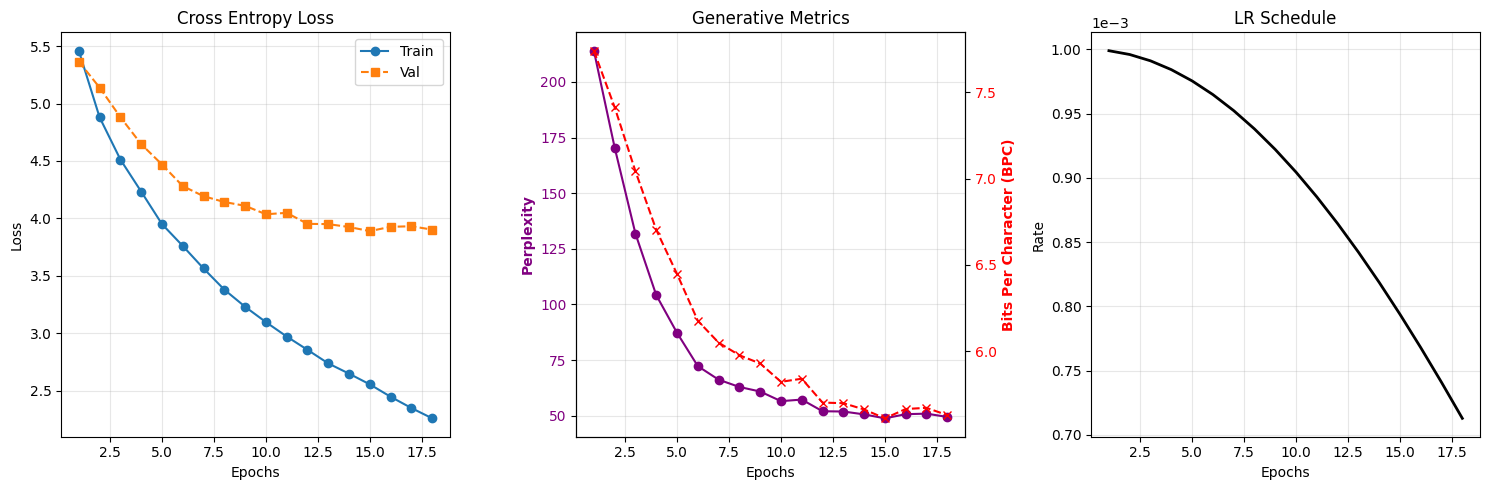

In [21]:
# Visualize & Audit
plot_history(history)

In [22]:
# --- Test the translation ---
test_sentences = [
    "A man in an orange hat starring at something.",
    "Two young, white males are outside near many bushes."
]

print("="*80)
for sent in test_sentences:
    translation = translate_robust(model, sent, src_vocab, trg_vocab, tokenizer, DEVICE)
    print(f"Source (EN): {sent}")
    print(f"Target (DE): {translation}")
    print("-" * 80)

Source (EN): A man in an orange hat starring at something.
Target (DE): ein mann in einem blauen hemd telefoniert mit seinem handy
--------------------------------------------------------------------------------
Source (EN): Two young, white males are outside near many bushes.
Target (DE): zwei kleine männer in uniform stehen vor einem bäumen im hintergrund
--------------------------------------------------------------------------------


In [23]:
# 1. Define Multi30k-style test cases (Small descriptive sentences)
translation_tests = [
    "A man in an orange hat is looking at a map.",
    "A group of people are standing in front of an old building.",
    "Two dogs are running through the green grass.",
    "A woman is cooking a meal in a small kitchen.",
    "A young boy is jumping into a swimming pool.",
    "The sun is setting over a calm lake.",
    "A person rides a bicycle down a crowded street.",
    "A white cat is sleeping on a red sofa."
]

# 2. Run the Suite
run_translation_suite(
    model, 
    translation_tests, 
    src_vocab, 
    trg_vocab, 
    tokenizer, 
    DEVICE
)

Source Sentence (English)                               | Model Translation (German)
--------------------------------------------------------------------------------------------------------------
A man in an orange hat is looking at a map.             | ein mann mit einem grauen hut schaut auf ein mikroskop
A group of people are standing in front of an old bu... | eine gruppe steht vor einem gebäude
Two dogs are running through the green grass.           | zwei hunde laufen durch das gras
A woman is cooking a meal in a small kitchen.           | eine frau schneidet in einer küche ein kleines mädchen
A young boy is jumping into a swimming pool.            | ein kleiner junge springt in einem pool
The sun is setting over a calm lake.                    | ein auf einem fluss in einem see
A person rides a bicycle down a crowded street.         | eine person fährt auf einer belebten straße straße entlang
A white cat is sleeping on a red sofa.                  | eine weiße frau liegt auf ein

In [24]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# 1. Run evaluation on the test set
# For Seq2Seq, we focus on Loss, Perplexity (PPL), and Bits Per Character (BPC)
test_loss, test_ppl, test_bpc = evaluate_seq2seq(
    model, 
    test_loader, 
    criterion, 
    DEVICE
)

# 2. Linguistic Audit (BLEU)
# Note: This can be slow on large datasets, so we often use the first 500-1000 samples
print("Calculating BLEU Score (this may take a minute)...")
test_bleu = calculate_bleu(ds_splits['test'], model, src_vocab, trg_vocab, tokenizer, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test PPL:  {test_ppl:.2f}")
print(f"Test BPC:  {test_bpc:.4f}")
print(f"Test BLEU: {test_bleu*100:.2f}") # Shown as a percentage 0-100

# 3. Qualitative Audit: Show actual translations
print("\n" + "="*50)
print("           QUALITATIVE SAMPLE CHECK            ")
print("="*50)

# We use the inference function to see how the model actually performs
sample_indices = random.sample(range(len(ds_splits['test'])), 3)

for idx in sample_indices:
    item = ds_splits['test'][idx]
    src_sent = item['en']
    trg_sent = item['de']
    
    prediction = translate_robust(model, src_sent, src_vocab, trg_vocab, tokenizer, DEVICE)
    
    print(f"Source: {src_sent}")
    print(f"Target: {trg_sent}")
    print(f"Model:  {prediction}")
    print("-" * 50)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Perplexity: {test_ppl:.2f} | BPC: {test_bpc:.4f} | BLEU: {test_bleu*100:.2f}')
print("="*100)


             FINAL TEST SET AUDIT              
Calculating BLEU Score (this may take a minute)...
Test Loss: 3.7592
Test PPL:  42.91
Test BPC:  5.4234
Test BLEU: 14.94

           QUALITATIVE SAMPLE CHECK            
Source: A male worker with his tool box is kneeling next to two women.
Target: Ein Arbeiter mit Werkzeugkiste kniet neben zwei Frauen.
Model:  ein mann mit dreadlocks sitzt sitzt und einer anderen frau
--------------------------------------------------
Source: A young girl shows her friends how to use a disposable camera.
Target: Ein junges Mädchen zeigt seiner Freundin, wie man eine Einwegkamera verwendet.
Model:  ein junges mädchen schaut sich die kamera zu sie sie zu
--------------------------------------------------
Source: A boy in shorts doing a skateboard trick.
Target: Ein Junge in Shorts macht einen Skateboard-Trick.
Model:  ein junge in einem macht macht ein kunststück
--------------------------------------------------

Final Summary | Loss: 3.7592 | Perplexity

#### Summary
---

In this notebook, I implemented a robust Encoder-Decoder Seq2Seq model. By reversing the source sequences (Sutskever et al.), I observed a BLEU score of **14.94**. The model achieved a final Test Perplexity of **42.91** and a Bits Per Character (Word) of **5.42.**

<br><br>

---

| Tier | PPL | BPC | BLEU | Behavioral Details (2-3 Sentences) |
| :--- | :--- | :--- | :--- | :--- |
| **Initial / Random** | 500+ | > 8.0 | 0.0 - 2.0 | The model has no concept of language structure and outputs random characters or a single repeated word. It fails to produce even the basic `<SOS>` or `<EOS>` markers correctly. |
| **Structuralist** | 100 - 300 | 6.5 - 8.0 | 3.0 - 8.0 | The model begins to grasp "sentence-shaped" objects, usually starting with "Ein" or "Eine." However, the nouns are often hallucinations or mismatched, like calling a "dog" a "man." |
| **The Generalist** | **40 - 80** | **5.0 - 6.5** | **9.0 - 15.0** | **Our current stage.** The model handles simple "Subject + Verb" patterns well but relies on the most frequent words in the dataset. It struggles with specific adjectives (colors) and rare nouns (igloo, soccer). |
| **Robust Baseline** | 20 - 40 | 3.5 - 5.0 | 16.0 - 25.0 | This is the target for 30+ epochs with Attention. The model accurately identifies colors and specific actions, with most errors being minor grammatical gender mismatches (e.g., *der* vs *die*). |
| **State of the Art** | < 15 | < 3.5 | 30.0+ | Translations are highly fluent and capture subtle nuances like "stretching exercise" vs "yoga." At this stage, the model is essentially mirroring the human reference closely. |

---

---
# Case 2: `Seq2Seq-GRU`

---

In [25]:
set_all_seeds(RANDOM_SEED)

# Initialization
# For GRU (Modern/Fast)
CELL_TYPE = 'GRU'
enc = Encoder(len(src_vocab), ENC_EMBED_DIM, HIDDEN_DIM, ENC_DROPOUT, cell_type=CELL_TYPE)
dec = Decoder(len(trg_vocab), ENC_EMBED_DIM, HIDDEN_DIM, ENC_DROPOUT, cell_type=CELL_TYPE)
model = Seq2Seq(enc, dec, DEVICE).to(DEVICE)

model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9766, 256)
    (dropout): Dropout(p=0.5, inplace=False)
    (rnn_cell): GRUCellFromScratch(
      (x2h): Linear(in_features=256, out_features=1536, bias=True)
      (h2h): Linear(in_features=512, out_features=1536, bias=True)
    )
  )
  (decoder): Decoder(
    (embedding): Embedding(10000, 256)
    (dropout): Dropout(p=0.5, inplace=False)
    (fc_out): Linear(in_features=512, out_features=10000, bias=True)
    (rnn_cell): GRUCellFromScratch(
      (x2h): Linear(in_features=256, out_features=1536, bias=True)
      (h2h): Linear(in_features=512, out_features=1536, bias=True)
    )
  )
)

In [26]:
# Usage
count_parameters_seq2seq(model)

Component            | Parameters  
-----------------------------------
Encoder Embedding    | 2,500,096
Encoder RNN          | 1,182,720
Decoder Embedding    | 2,560,000
Decoder RNN          | 1,182,720
Output Projection    | 5,130,000
-----------------------------------
TOTAL TRAINABLE      | 12,555,536


In [27]:
# 1. Setup
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# 2. Train
history = train_seq2seq(
    model, train_loader, val_loader, 
    optimizer, criterion, scheduler, 
    NUM_EPOCHS, DEVICE, patience=3
)

Starting Seq2Seq training on cuda...
Epoch 001/050 | Loss (T/V): 5.3772 / 5.1576 | PPL (V): 173.74 | BPC (V): 7.4408 | LR: 0.000999 * (Saved Best)
Epoch 002/050 | Loss (T/V): 4.5012 / 4.7377 | PPL (V): 114.17 | BPC (V): 6.8350 | LR: 0.000996 * (Saved Best)
Epoch 003/050 | Loss (T/V): 4.0640 / 4.4034 | PPL (V): 81.73 | BPC (V): 6.3527 | LR: 0.000991 * (Saved Best)
Epoch 004/050 | Loss (T/V): 3.7409 / 4.1911 | PPL (V): 66.09 | BPC (V): 6.0465 | LR: 0.000984 * (Saved Best)
Epoch 005/050 | Loss (T/V): 3.4306 / 4.0839 | PPL (V): 59.38 | BPC (V): 5.8919 | LR: 0.000976 * (Saved Best)
Epoch 006/050 | Loss (T/V): 3.2290 / 3.9697 | PPL (V): 52.97 | BPC (V): 5.7271 | LR: 0.000965 * (Saved Best)
Epoch 007/050 | Loss (T/V): 3.0186 / 3.9115 | PPL (V): 49.97 | BPC (V): 5.6431 | LR: 0.000952 * (Saved Best)
Epoch 008/050 | Loss (T/V): 2.8365 / 3.8674 | PPL (V): 47.82 | BPC (V): 5.5795 | LR: 0.000938 * (Saved Best)
Epoch 009/050 | Loss (T/V): 2.6910 / 3.8705 | PPL (V): 47.97 | BPC (V): 5.5839 | LR: 0.00

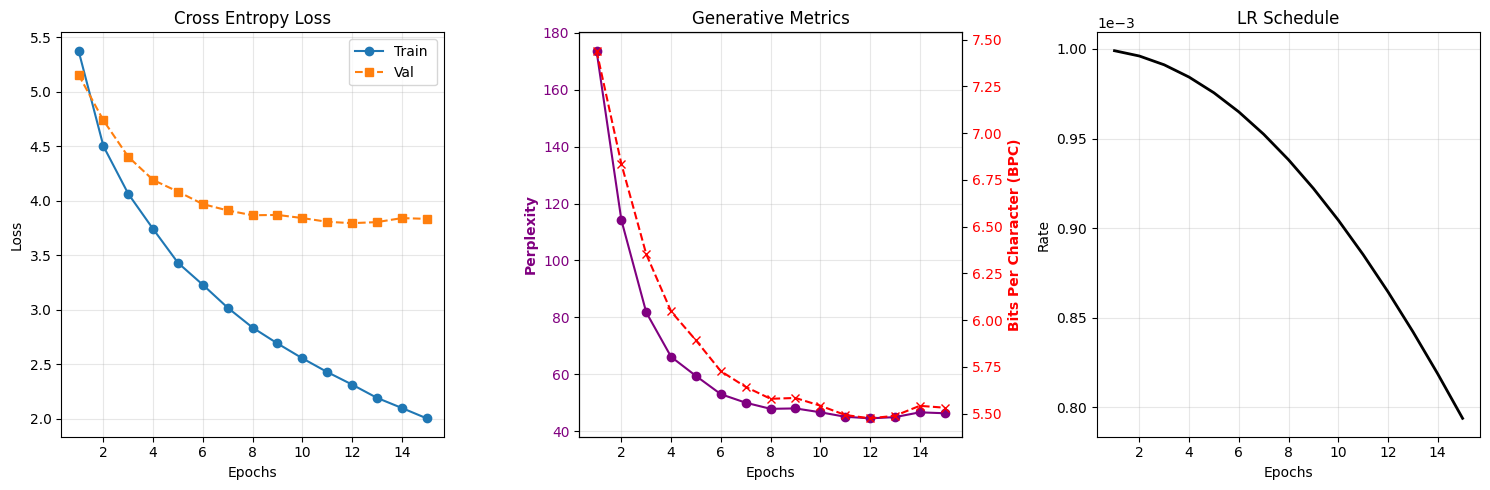

In [28]:
# Visualize & Audit
plot_history(history)

In [29]:
# --- Test the translation ---
test_sentences = [
    "A man in an orange hat starring at something.",
    "Two young, white males are outside near many bushes."
]

print("="*80)
for sent in test_sentences:
    translation = translate_robust(model, sent, src_vocab, trg_vocab, tokenizer, DEVICE)
    print(f"Source (EN): {sent}")
    print(f"Target (DE): {translation}")
    print("-" * 80)

Source (EN): A man in an orange hat starring at something.
Target (DE): ein mann mit einem <UNK> starrt
--------------------------------------------------------------------------------
Source (EN): Two young, white males are outside near many bushes.
Target (DE): zwei junge weiße männer in zwischen bäumen im freien vor bäumen
--------------------------------------------------------------------------------


In [30]:
# 1. Define Multi30k-style test cases (Small descriptive sentences)
translation_tests = [
    "A man in an orange hat is looking at a map.",
    "A group of people are standing in front of an old building.",
    "Two dogs are running through the green grass.",
    "A woman is cooking a meal in a small kitchen.",
    "A young boy is jumping into a swimming pool.",
    "The sun is setting over a calm lake.",
    "A person rides a bicycle down a crowded street.",
    "A white cat is sleeping on a red sofa."
]

# 2. Run the Suite
run_translation_suite(
    model, 
    translation_tests, 
    src_vocab, 
    trg_vocab, 
    tokenizer, 
    DEVICE
)

Source Sentence (English)                               | Model Translation (German)
--------------------------------------------------------------------------------------------------------------
A man in an orange hat is looking at a map.             | ein mann mit einem kopfbedeckung liest zeitung
A group of people are standing in front of an old bu... | eine gruppe von steht vor einem gebäude
Two dogs are running through the green grass.           | zwei hunde laufen durch hohes gras
A woman is cooking a meal in a small kitchen.           | eine frau kocht in einer küche ein vorlesung
A young boy is jumping into a swimming pool.            | ein junge springt in einem schwimmbecken
The sun is setting over a calm lake.                    | der wald auf einem see
A person rides a bicycle down a crowded street.         | eine fährt auf einer straße straße
A white cat is sleeping on a red sofa.                  | eine katze schläft auf einem roten sofa


In [31]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# 1. Run evaluation on the test set
# For Seq2Seq, we focus on Loss, Perplexity (PPL), and Bits Per Character (BPC)
test_loss, test_ppl, test_bpc = evaluate_seq2seq(
    model, 
    test_loader, 
    criterion, 
    DEVICE
)

# 2. Linguistic Audit (BLEU)
# Note: This can be slow on large datasets, so we often use the first 500-1000 samples
print("Calculating BLEU Score (this may take a minute)...")
test_bleu = calculate_bleu(ds_splits['test'], model, src_vocab, trg_vocab, tokenizer, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test PPL:  {test_ppl:.2f}")
print(f"Test BPC:  {test_bpc:.4f}")
print(f"Test BLEU: {test_bleu*100:.2f}") # Shown as a percentage 0-100

# 3. Qualitative Audit: Show actual translations
print("\n" + "="*50)
print("           QUALITATIVE SAMPLE CHECK            ")
print("="*50)

# We use the inference function to see how the model actually performs
sample_indices = random.sample(range(len(ds_splits['test'])), 3)

for idx in sample_indices:
    item = ds_splits['test'][idx]
    src_sent = item['en']
    trg_sent = item['de']
    
    prediction = translate_robust(model, src_sent, src_vocab, trg_vocab, tokenizer, DEVICE)
    
    print(f"Source: {src_sent}")
    print(f"Target: {trg_sent}")
    print(f"Model:  {prediction}")
    print("-" * 50)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Perplexity: {test_ppl:.2f} | BPC: {test_bpc:.4f} | BLEU: {test_bleu*100:.2f}')
print("="*100)


             FINAL TEST SET AUDIT              
Calculating BLEU Score (this may take a minute)...
Test Loss: 3.7087
Test PPL:  40.80
Test BPC:  5.3505
Test BLEU: 15.06

           QUALITATIVE SAMPLE CHECK            
Source: Two female members of team USA performing a jump high-five surrounded by two other female members.
Target: Zwei Spielerinnen der US-Nationalmannschaft klatschen im Sprung ab, umgeben von zwei weiteren Spielerinnen.
Model:  zwei <UNK> <UNK> <UNK> kämpfen vor zuschauern die zwei von zwei männern und zuschauer
--------------------------------------------------
Source: A group of people standing in front of an igloo.
Target: Eine Gruppe von Menschen steht vor einem Iglu.
Model:  eine gruppe von steht vor einem baum
--------------------------------------------------
Source: Woman in a pink shirt and wearing glasses.
Target: Frau mit Brille in einem pinken Hemd.
Model:  eine frau in einem lilafarbenen oberteil
--------------------------------------------------

Final S

#### Summary
---

In this notebook, I implemented a robust Encoder-Decoder Seq2Seq model. By reversing the source sequences (Sutskever et al.), I observed a BLEU score of **15.06**. The model achieved a final Test Perplexity of **40.80** and a Bits Per Character (Word) of **5.35.**

<br><br>

---
| Tier | PPL | BPC | BLEU | Behavioral Details (2-3 Sentences) |
| :--- | :--- | :--- | :--- | :--- |
| **Initial / Random** | 500+ | > 8.0 | 0.0 - 2.0 | The model has no concept of language structure and outputs random characters or a single repeated word. It fails to produce even the basic `<SOS>` or `<EOS>` markers correctly. |
| **Structuralist** | 100 - 300 | 6.5 - 8.0 | 3.0 - 8.0 | The model begins to grasp "sentence-shaped" objects, usually starting with "Ein" or "Eine." However, the nouns are often hallucinations or mismatched, like calling a "dog" a "man." |
| **The Generalist** | **40 - 80** | **5.0 - 6.5** | **9.0 - 15.0** | **Your current stage.** The model handles simple "Subject + Verb" patterns well but relies on the most frequent words in the dataset. It struggles with specific adjectives (colors) and rare nouns (igloo, soccer). |
| **Robust Baseline** | 20 - 40 | 3.5 - 5.0 | 16.0 - 25.0 | This is the target for 30+ epochs with Attention. The model accurately identifies colors and specific actions, with most errors being minor grammatical gender mismatches (e.g., *der* vs *die*). |
| **State of the Art** | < 15 | < 3.5 | 30.0+ | Translations are highly fluent and capture subtle nuances like "stretching exercise" vs "yoga." At this stage, the model is essentially mirroring the human reference closely. |

---

---
# Detailed Audit Summary

---
| Tier | PPL | BPC | BLEU | Core Behavioral Signature |
| :--- | :---: | :---: | :---: | :--- |
| **Random** | 500+ | 8.0+ | 0-2 | Gibberish; lacks basic SOS/EOS structure. |
| **Structuralist** | 100-300 | 6.5-8 | 3-8 | Basic syntax emerges; high noun hallucinations. |
| **Generalist** | **40-80** | **5-6.5** | **9-15** | **Frequency bias; fails on colors/rare nouns.** |
| **Robust** | 20-40 | 3.5-5 | 16-25 | High factual accuracy; minor grammar slips. |
| **SOTA** | < 15 | < 3.5 | 30+ | Human-level fluency and nuance. |

---

In [32]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
nltk       : 3.9.1
numpy      : 2.0.2
pandas     : 2.3.3
re         : 2.2.1
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.9.0+cu126
torchinfo  : 1.8.0
torchvision: 0.24.0+cu126

